In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
# Aplicar configuraciones de visualización total de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

from prophet import Prophet

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:


def graficar_tendencia (forecast1, columna, fecha):
    # ==============================================================================
    # 1. FILTRADO VECTORIAL Y PREPARACIÓN DE DATOS
    # ==============================================================================
    # Asegurar el tipo datetime para el filtro correcto
    forecast1["ds"] = pd.to_datetime(forecast1["ds"])

    # Filtrar a partir del 1 de enero de 2026
    df_plot = forecast1[forecast1["ds"] > fecha].copy()

    # Transformar a formato largo (long-format) para optimizar el mapeo en Seaborn
    df_long = df_plot.melt(
        id_vars=["ds"],
        value_vars=["y", columna],
        var_name="Metrica",
        value_name="Valor",
    )

    # ==============================================================================
    # 2. CONFIGURACIÓN Y GENERACIÓN DEL GRÁFICO (SEABORN)
    # ==============================================================================
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 6))

    # Graficar líneas con diferenciación por estilo y color
    sns.lineplot(
        data=df_long,
        x="ds",
        y="Valor",
        hue="Metrica",
        style="Metrica",
        palette={"y": "#1f77b4", columna: "#ff7f0e"},  # Azul para real, Naranja para predicción
        linewidth=2,
    )

    # ==============================================================================
    # 3. BUENAS PRÁCTICAS YESTÉTICA DE EJES
    # ==============================================================================
    plt.title(
        "Comparativa de Ventas Reales (y) vs. Predicción (yhat) - Post 2026",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Fecha (ds)", fontsize=11, labelpad=10)
    plt.ylabel("Ventas (Valor)", fontsize=11, labelpad=10)

    # Rotar etiquetas del eje X para mejorar la lectura de las fechas
    plt.xticks(rotation=45)

    plt.legend(title="Métrica", frameon=True, facecolor="white", edgecolor="none")
    plt.tight_layout()

    # Mostrar gráfico
    plt.show()

In [5]:
df = pd.read_parquet(r"files\fact_ventas_predict.parquet")

In [130]:
df_venta_cero = df[(df["ds"].dt.month==1)&(df["ds"].dt.day==1)].groupby("llave")["y"].sum().reset_index()
list_local_open = df_venta_cero[df_venta_cero["y"]>500]["llave"].unique().tolist()

In [8]:
list_llaves = df["llave"].unique().tolist()

In [162]:
df[~((df["y"]==0)&(~(df["ds"].dt.month==1)&(df["ds"].dt.day==1)))]

,DivArea,Codigo Local,ds,y,llave,black_friday,dia_de_la_madre,dia_del_padre,efecto_fin_mes,efecto_quincena,fiestas_patrias,halloween,navidad,nuevo_año,post_año_nuevo,post_navidad,pre_navidad,pre_nuevo_año,san_valentin,semana_santa
0,D1A01,1198,2024-01-01,0.00,1198-D1A01,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,D1A01,1198,2024-01-02,16494.47,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,D1A01,1198,2024-01-03,12344.29,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,D1A01,1198,2024-01-04,12596.64,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,D1A01,1198,2024-01-05,12533.60,1198-D1A01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400659,D4A14,X210,2026-04-26,77.84,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1400660,D4A14,X210,2026-04-27,53.20,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1400661,D4A14,X210,2026-04-28,61.48,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1400662,D4A14,X210,2026-04-29,32.39,X210-D4A14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [197]:
llave = "V095-D1A01"
df1 = df[~((df["y"]==0)&(~(df["ds"].dt.month==1)&(df["ds"].dt.day==1)))]
dff = df1[df1["llave"]==llave]
dff_01 = dff[dff["ds"]<"2026-01-01"]
dff_02 = dff[dff["ds"]<"2026-02-01"]
dff_03 = dff[dff["ds"]<"2026-03-01"]
dff_04 = dff[dff["ds"]<"2026-04-01"]

22:05:05 - cmdstanpy - INFO - Chain [1] start processing
22:05:05 - cmdstanpy - INFO - Chain [1] done processing


--- RENDIMIENTO DE PROPHET ---
Train RMSE: 4111.1993
Test RMSE: 6909.5763
Train R2: 0.3502
Test R2: -0.1792
ErrorMes: 1.0746
--- RENDIMIENTO DE ENSAMBLE ---
Train RMSE: 2963.5414
Test RMSE: 3160.3792
Train R2: 0.6623
Test R2: 0.3998
ErrorMes: 1.0415


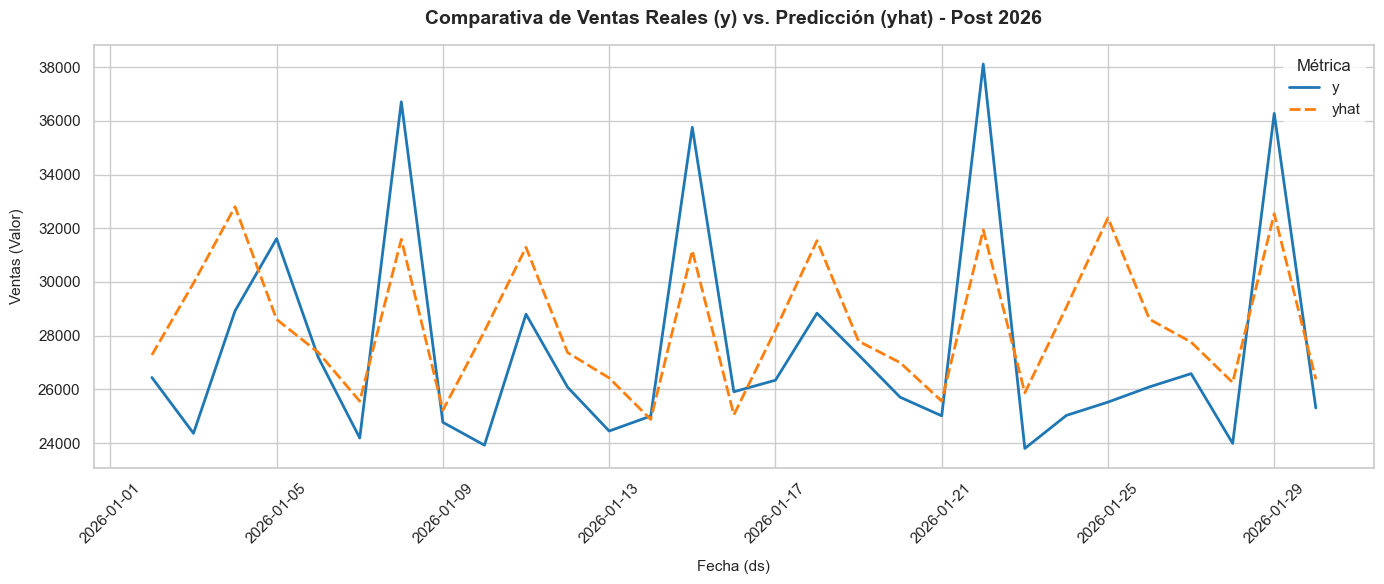

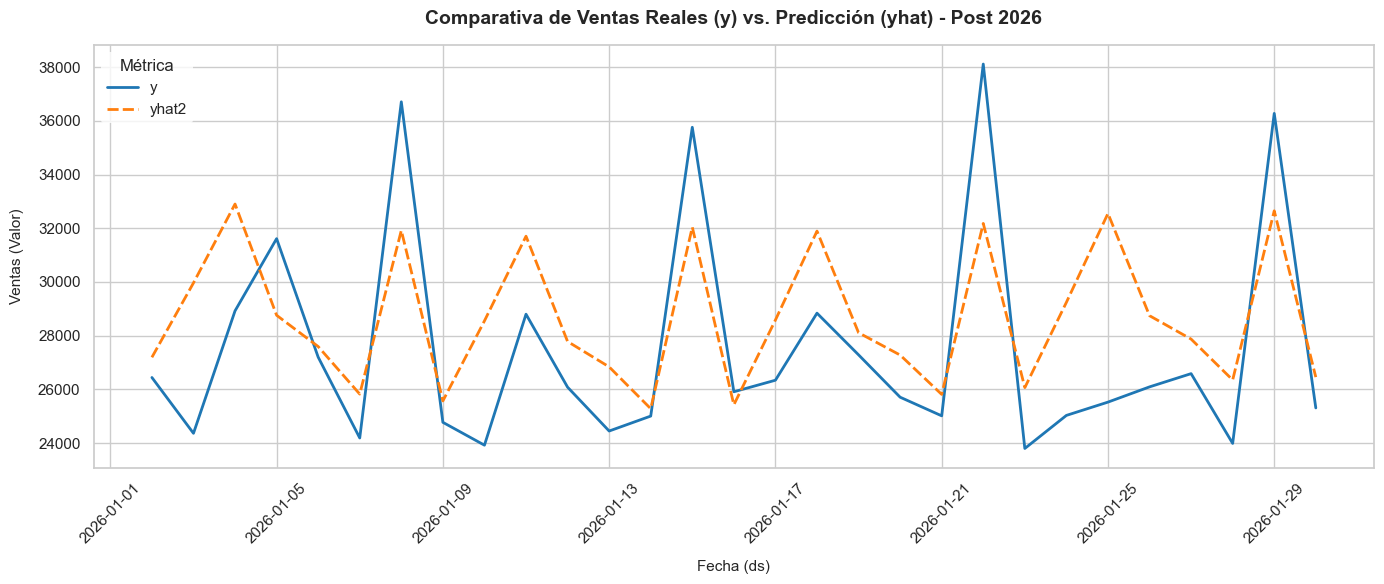

In [198]:
dff_01_prophet = dff_01[["ds", "y"]]
fecha = "2026-01-01"
model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        seasonality_prior_scale = 10,
        changepoint_prior_scale = 0.05
    )

model.fit(dff_01_prophet)

future = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

forecast1 = forecast[["ds", "trend", "weekly", "yearly", "yhat"]].merge(dff.drop(columns=["DivArea", "Codigo Local", "llave"]), on="ds", how="left")
forecast1 = forecast1.fillna(0)

X_train = forecast1[forecast1["ds"]<fecha].drop(columns=["y", "ds", "yhat"])
y_train = forecast1[forecast1["ds"]<fecha]["y"]

X_test = forecast1[forecast1["ds"]>=fecha].drop(columns=["y", "ds", "yhat"])
y_test = forecast1[forecast1["ds"]>=fecha]["y"]

model = LinearRegression(n_jobs=-1)  # n_jobs=-1 utiliza todos los cores disponibles
model.fit(X_train, y_train)

# Inferencia
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_total = np.concatenate([y_pred_train, y_pred_test])
forecast1["yhat2"] = y_pred_total

if llave in list_local_open:
    pass
else:
    # Si no está en la lista, el local está cerrado: forzar la predicción a 0 de forma vectorizada
    forecast1["yhat2"] = np.where((forecast1["ds"].dt.month==1)&(forecast1["ds"].dt.day==1), 0, forecast1["yhat2"])

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>=fecha]["y"], forecast1[forecast1["ds"]>=fecha]["yhat"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>=fecha]["y"], forecast1[forecast1["ds"]>=fecha]["yhat"]),
    "ErrorMes" : forecast1[forecast1["ds"]>=fecha]["yhat"].sum()/forecast1[forecast1["ds"]>=fecha]["y"].sum()
}

print("--- RENDIMIENTO DE PROPHET ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"]),
    "ErrorMes" : forecast1[forecast1["ds"]>=fecha]["yhat2"].sum()/forecast1[forecast1["ds"]>=fecha]["y"].sum()
}

print("--- RENDIMIENTO DE ENSAMBLE ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

graficar_tendencia(forecast1, "yhat", fecha)
graficar_tendencia(forecast1, "yhat2", fecha)

22:05:06 - cmdstanpy - INFO - Chain [1] start processing
22:05:06 - cmdstanpy - INFO - Chain [1] done processing


--- RENDIMIENTO DE PROPHET ---
Train RMSE: 4244.4888
Test RMSE: 3393.8793
Train R2: 0.3435
Test R2: 0.3885
ErrorMes: 1.0054
--- RENDIMIENTO DE ENSAMBLE ---
Train RMSE: 2961.4428
Test RMSE: 3504.0086
Train R2: 0.6804
Test R2: 0.3482
ErrorMes: 1.0253


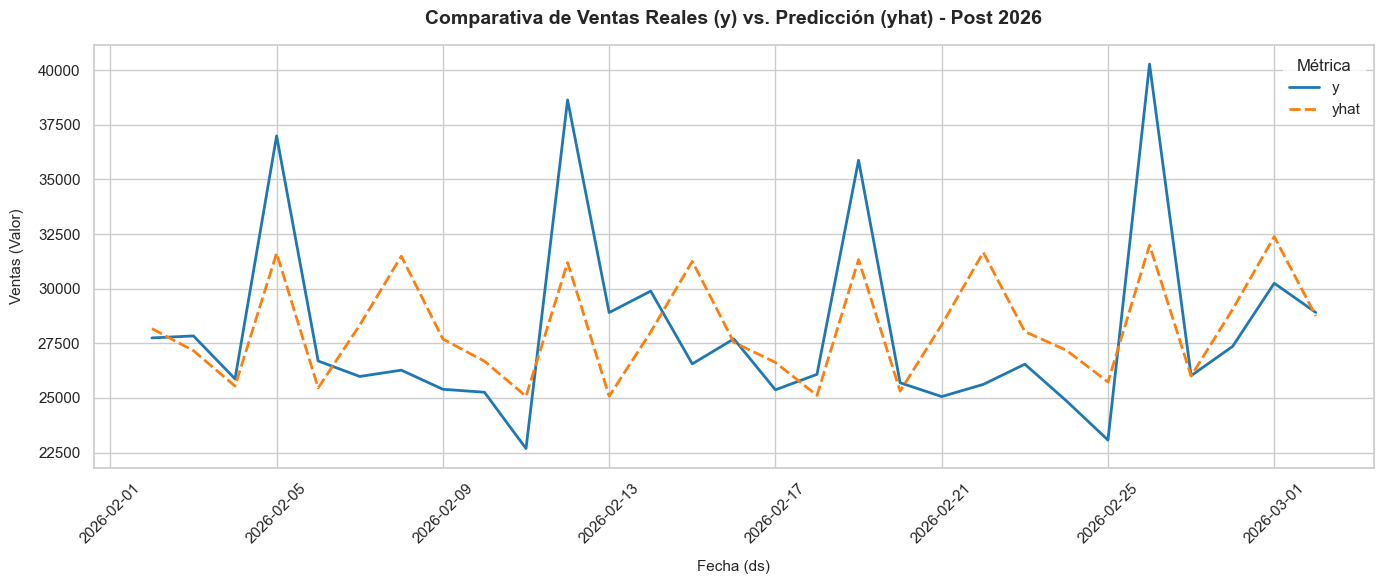

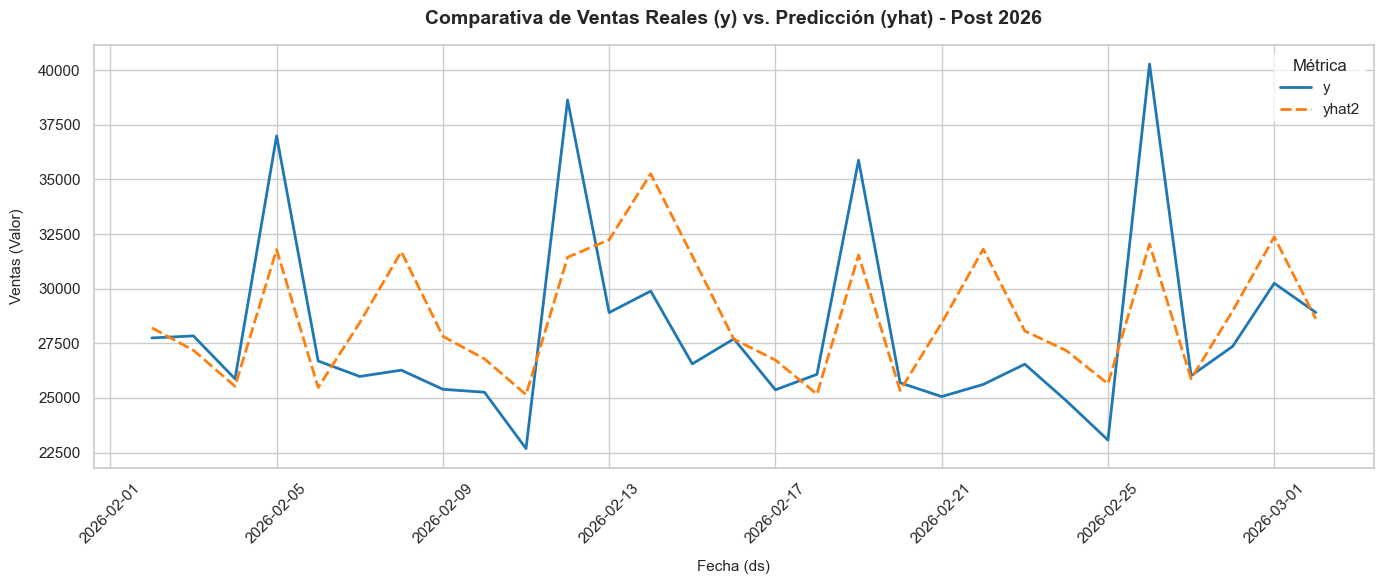

In [199]:
dff_01_prophet = dff_02[["ds", "y"]]
fecha = "2026-02-01"
model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        seasonality_prior_scale = 10,
        changepoint_prior_scale = 0.05
    )

model.fit(dff_01_prophet)

future = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

forecast1 = forecast[["ds", "trend", "weekly", "yearly", "yhat"]].merge(dff.drop(columns=["DivArea", "Codigo Local", "llave"]), on="ds", how="left")



X_train = forecast1[forecast1["ds"]<fecha].drop(columns=["y", "ds", "yhat"])
y_train = forecast1[forecast1["ds"]<fecha]["y"]

X_test = forecast1[forecast1["ds"]>=fecha].drop(columns=["y", "ds", "yhat"])
y_test = forecast1[forecast1["ds"]>=fecha]["y"]

model = LinearRegression(n_jobs=-1)  # n_jobs=-1 utiliza todos los cores disponibles
model.fit(X_train, y_train)

# Inferencia
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_total = np.concatenate([y_pred_train, y_pred_test])
forecast1["yhat2"] = y_pred_total

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat"]),
    "ErrorMes" : forecast1[forecast1["ds"]>fecha]["yhat"].sum()/forecast1[forecast1["ds"]>fecha]["y"].sum()
}

print("--- RENDIMIENTO DE PROPHET ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"]),
    "ErrorMes" : forecast1[forecast1["ds"]>fecha]["yhat2"].sum()/forecast1[forecast1["ds"]>fecha]["y"].sum()
}

print("--- RENDIMIENTO DE ENSAMBLE ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

graficar_tendencia(forecast1, "yhat", fecha)
graficar_tendencia(forecast1, "yhat2", fecha)

22:05:06 - cmdstanpy - INFO - Chain [1] start processing
22:05:06 - cmdstanpy - INFO - Chain [1] done processing


--- RENDIMIENTO DE PROPHET ---
Train RMSE: 4221.8857
Test RMSE: 2857.7740
Train R2: 0.3527
Test R2: 0.6594
ErrorMes: 1.0076
--- RENDIMIENTO DE ENSAMBLE ---
Train RMSE: 2976.9914
Test RMSE: 2747.6095
Train R2: 0.6781
Test R2: 0.6851
ErrorMes: 0.9969


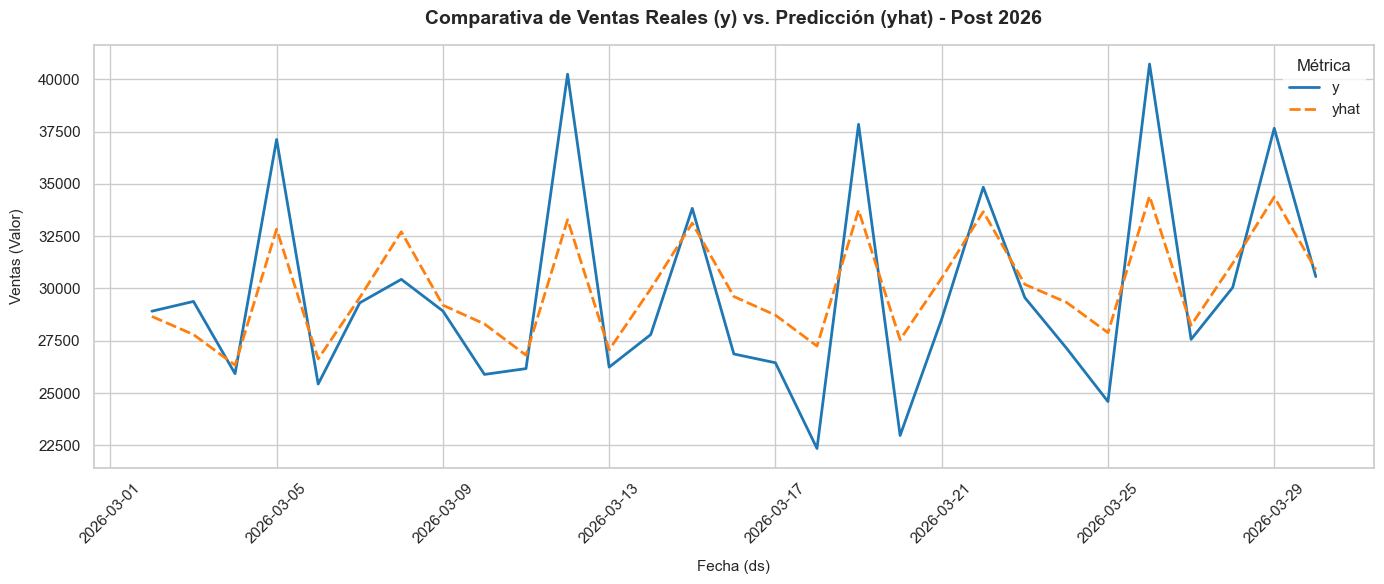

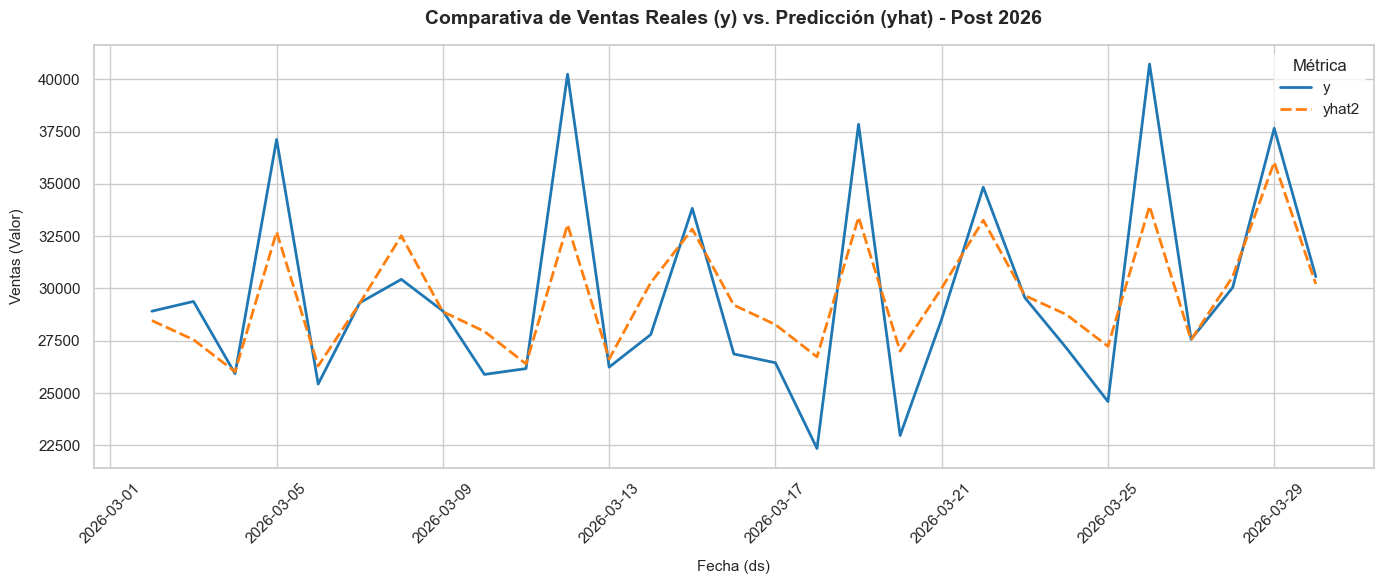

In [200]:
dff_01_prophet = dff_03[["ds", "y"]]
fecha = "2026-03-01"
model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        seasonality_prior_scale = 10,
        changepoint_prior_scale = 0.05
    )

model.fit(dff_01_prophet)

future = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

forecast1 = forecast[["ds", "trend", "weekly", "yearly", "yhat"]].merge(dff.drop(columns=["DivArea", "Codigo Local", "llave"]), on="ds", how="left")



X_train = forecast1[forecast1["ds"]<fecha].drop(columns=["y", "ds", "yhat"])
y_train = forecast1[forecast1["ds"]<fecha]["y"]

X_test = forecast1[forecast1["ds"]>=fecha].drop(columns=["y", "ds", "yhat"])
y_test = forecast1[forecast1["ds"]>=fecha]["y"]

model = LinearRegression(n_jobs=-1)  # n_jobs=-1 utiliza todos los cores disponibles
model.fit(X_train, y_train)

# Inferencia
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_total = np.concatenate([y_pred_train, y_pred_test])
forecast1["yhat2"] = y_pred_total

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat"]),
    "ErrorMes" : forecast1[forecast1["ds"]>fecha]["yhat"].sum()/forecast1[forecast1["ds"]>fecha]["y"].sum()
}

print("--- RENDIMIENTO DE PROPHET ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"]),
    "ErrorMes" : forecast1[forecast1["ds"]>fecha]["yhat2"].sum()/forecast1[forecast1["ds"]>fecha]["y"].sum()
}

print("--- RENDIMIENTO DE ENSAMBLE ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

graficar_tendencia(forecast1, "yhat", fecha)
graficar_tendencia(forecast1, "yhat2", fecha)

22:05:07 - cmdstanpy - INFO - Chain [1] start processing
22:05:07 - cmdstanpy - INFO - Chain [1] done processing


--- RENDIMIENTO DE PROPHET ---
Train RMSE: 4176.4149
Test RMSE: 3393.5107
Train R2: 0.3636
Test R2: 0.5788
ErrorMes: 1.0244
--- RENDIMIENTO DE ENSAMBLE ---
Train RMSE: 2962.2828
Test RMSE: 3113.6980
Train R2: 0.6798
Test R2: 0.6454
ErrorMes: 1.0074


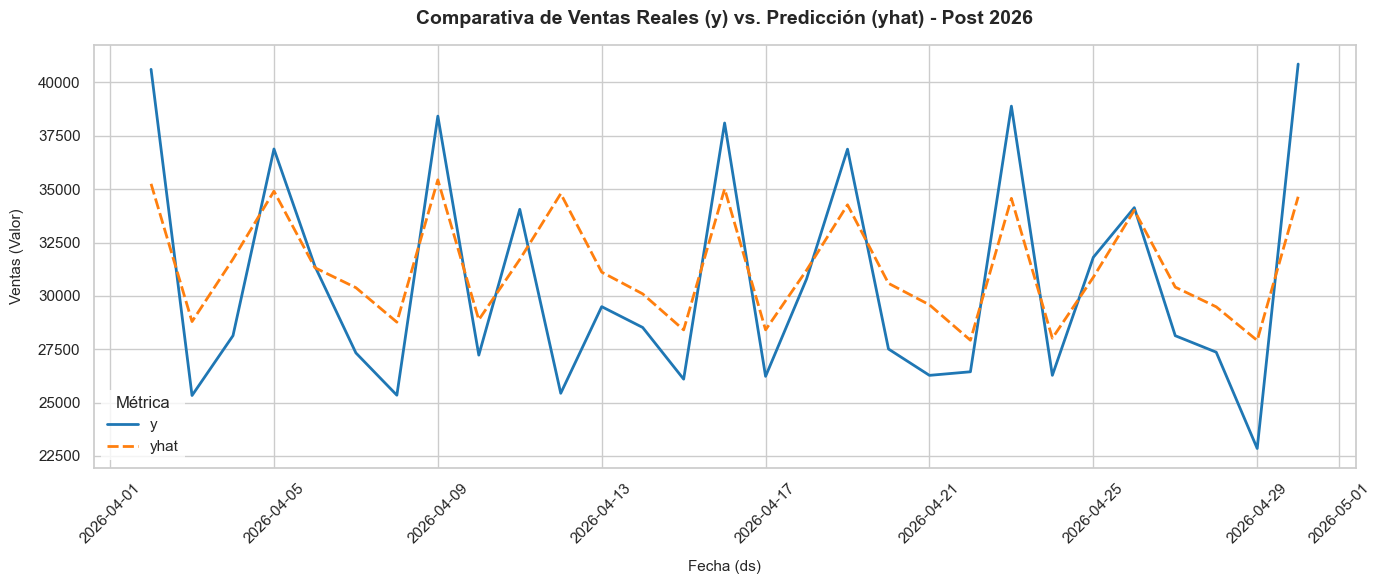

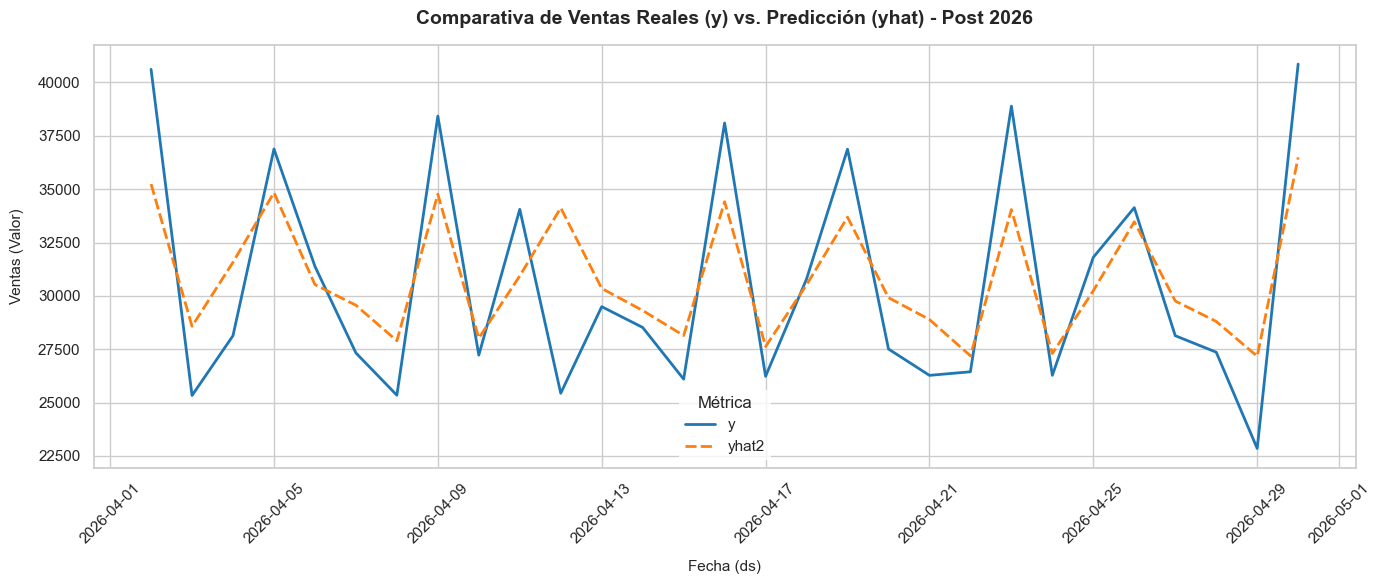

In [201]:
dff_01_prophet = dff_04[["ds", "y"]]
fecha = "2026-04-01"
model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        seasonality_prior_scale = 10,
        changepoint_prior_scale = 0.05
    )

model.fit(dff_01_prophet)

future = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

forecast1 = forecast[["ds", "trend", "weekly", "yearly", "yhat"]].merge(dff.drop(columns=["DivArea", "Codigo Local", "llave"]), on="ds", how="left")



X_train = forecast1[forecast1["ds"]<fecha].drop(columns=["y", "ds", "yhat"])
y_train = forecast1[forecast1["ds"]<fecha]["y"]

X_test = forecast1[forecast1["ds"]>=fecha].drop(columns=["y", "ds", "yhat"])
y_test = forecast1[forecast1["ds"]>=fecha]["y"]

model = LinearRegression(n_jobs=-1)  # n_jobs=-1 utiliza todos los cores disponibles
model.fit(X_train, y_train)

# Inferencia
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_total = np.concatenate([y_pred_train, y_pred_test])
forecast1["yhat2"] = y_pred_total

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat"]),
    "ErrorMes" : forecast1[forecast1["ds"]>fecha]["yhat"].sum()/forecast1[forecast1["ds"]>fecha]["y"].sum()
}

print("--- RENDIMIENTO DE PROPHET ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"])),
    "Test RMSE": np.sqrt(mean_squared_error(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"])),
    "Train R2": r2_score(forecast1[forecast1["ds"]<fecha]["y"], forecast1[forecast1["ds"]<fecha]["yhat2"]),
    "Test R2": r2_score(forecast1[forecast1["ds"]>fecha]["y"], forecast1[forecast1["ds"]>fecha]["yhat2"]),
    "ErrorMes" : forecast1[forecast1["ds"]>fecha]["yhat2"].sum()/forecast1[forecast1["ds"]>fecha]["y"].sum()
}

print("--- RENDIMIENTO DE ENSAMBLE ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

graficar_tendencia(forecast1, "yhat", fecha)
graficar_tendencia(forecast1, "yhat2", fecha)

In [202]:
forecast1

,ds,trend,weekly,yearly,yhat,y,black_friday,dia_de_la_madre,dia_del_padre,efecto_fin_mes,efecto_quincena,fiestas_patrias,halloween,navidad,nuevo_año,post_año_nuevo,post_navidad,pre_navidad,pre_nuevo_año,san_valentin,semana_santa,yhat2
0,2024-01-01,30578.629695,-330.575244,-1178.331216,29069.723235,0.00,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-938.091732
1,2024-01-02,30584.648522,-1276.926890,-1621.415323,27686.306309,32206.64,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27583.910866
2,2024-01-03,30590.667349,-2888.104518,-2032.393685,25670.169146,31857.33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25602.799846
3,2024-01-04,30596.686176,3797.718801,-2406.472136,31987.932842,27402.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32194.529554
4,2024-01-05,30602.705003,-2726.863822,-2739.751698,25136.089483,26601.96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25216.548784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,2026-04-26,30113.811908,3281.284608,614.872950,34009.969467,34133.68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33471.654427
846,2026-04-27,30110.000727,-330.575244,630.383794,30409.809277,28133.94,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29760.193723
847,2026-04-28,30106.189546,-1276.926890,658.322385,29487.585040,27362.66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28803.317952
848,2026-04-29,30102.378365,-2888.104518,697.914999,27912.188845,22851.69,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27171.238067
